# Predicting fan_speed and light_intensity using Decision Tree

This notebook uses a Decision Tree Classifier to predict smart-room actuator
levels from sensor data collected by an ESP32 (IR-based occupancy counter,
a CO2 air-quality sensor, LDR, and DHT11 temperature/humidity sensor).

We are going to take the following approach:

1. Problem definition
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation

## 1. Problem definition

In a statement,
> Given occupancy count, motion state, temperature, humidity, and light
> level readings from the room, can we predict the appropriate fan speed
> and light intensity level (0-4) automatically?

## 2. Data

The dataset is synthetically generated to mirror real ESP32 sensor readings:
IR-sensor-derived occupancy `count`, an air-quality `co2_level` sensor,
`ldr_diff`, and DHT11 `temp`/`humidity`, with the two target levels
`fan_speed` and `light_intensity` (0-4) built from a noisy, non-trivial
combination of the inputs so the model has to actually learn the
relationship.

## 3. Evaluation

> If we can reach a reasonably high accuracy (and sensible confusion matrix)
> predicting both fan_speed and light_intensity, the model is good enough to
> deploy on the ESP32 -> MQTT -> actuator pipeline.

## 4. Features

**Data dictionary**

1. `count` - number of people currently in the room (derived from dual IR
   sensor sequence logic), range 0-30
2. `co2_level` - CO2 concentration in ppm, range 200-2500 (kept as a minor
   signal only - the physical prototype has no real occupants raising CO2,
   so both targets deliberately lean on it very little)
3. `ldr_diff` - outside LDR reading minus inside LDR reading, range roughly
   -2500 to 4000 (0-4095 ADC each). Positive = outside brighter than
   inside (room needs supplemental light); near-zero or negative = no
   light needed
4. `temp` - temperature in °C from DHT11, range 15-55
5. `humidity` - relative humidity % from DHT11, range 45-85
6. `fan_speed` - target label, fan speed level 0-4 (predicted mostly from
   `temp`, `humidity`, `count`, with a small `co2_level` contribution)
7. `light_intensity` - target label, light level 0-4 (predicted mostly from
   `ldr_diff` and `count`, with a small `co2_level` contribution)


# Preparing the tools

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import sklearn
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score

## Load data

In [2]:
df = pd.read_csv("sensor_dataset.csv")
df.shape

(8000, 7)

## Data Exploration (EDA)

The goal here is to find out more about the data and become a subject
matter expert on the dataset we're working with.

1. What question(s) are we trying to solve?
2. What kind of data do we have and how do we treat different types?
3. What's missing from the data and how do we deal with it?
4. Where are the outliers and why should we care about them?
5. How can we add, change or remove features to get more out of the data?

In [3]:
df.head()

,count,co2_level,temp,humidity,ldr_diff,fan_speed,light_intensity
0,26,1668,20.8,51.5,3115,1,4
1,9,846,48.4,52.8,-905,2,0
2,17,1359,37.7,50.7,-1106,2,1
3,4,689,37.0,65.1,2154,2,1
4,17,1469,49.8,65.0,2885,4,3


In [4]:
df.tail()

,count,co2_level,temp,humidity,ldr_diff,fan_speed,light_intensity
7995,22,1599,25.4,56.5,-294,2,2
7996,10,893,36.9,77.2,-2183,2,0
7997,27,1912,46.3,64.8,-2439,3,1
7998,18,1221,26.2,62.7,-304,2,1
7999,16,1441,45.4,74.3,3083,3,3


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   count            8000 non-null   int64  
 1   co2_level        8000 non-null   int64  
 2   temp             8000 non-null   float64
 3   humidity         8000 non-null   float64
 4   ldr_diff         8000 non-null   int64  
 5   fan_speed        8000 non-null   int64  
 6   light_intensity  8000 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 437.6 KB


In [6]:
# Are there any missing values?
df.isna().sum()

count              0
co2_level          0
temp               0
humidity           0
ldr_diff           0
fan_speed          0
light_intensity    0
dtype: int64

In [7]:
df.describe()

,count,co2_level,temp,humidity,ldr_diff,fan_speed,light_intensity
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,15.137750,1231.538500,34.943238,65.128613,344.951125,2.152750,1.262375
std,8.949108,527.466673,9.551438,9.549037,1386.542783,0.944738,1.031948
min,0.000000,200.000000,15.000000,45.000000,-2497.000000,0.000000,0.000000
25%,7.000000,802.000000,28.200000,58.400000,-570.000000,2.000000,0.000000
50%,15.000000,1240.000000,34.900000,65.200000,207.000000,2.000000,1.000000
75%,23.000000,1665.000000,41.600000,71.900000,1331.000000,3.000000,2.000000
max,30.000000,2495.000000,55.000000,85.000000,3962.000000,4.000000,4.000000


## fan_speed and light_intensity distribution

In [8]:
df.fan_speed.value_counts().sort_index()

fan_speed
0     352
1    1410
2    3488
3    2164
4     586
Name: count, dtype: int64

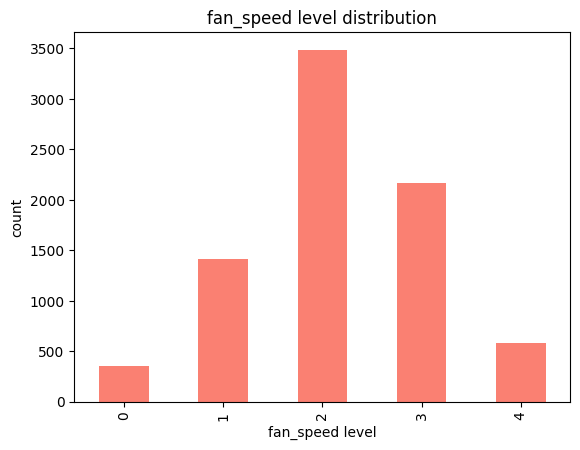

In [9]:
df.fan_speed.value_counts().sort_index().plot(kind="bar", color="salmon")
plt.title("fan_speed level distribution")
plt.xlabel("fan_speed level")
plt.ylabel("count");

In [10]:
df.light_intensity.value_counts().sort_index()

light_intensity
0    2111
1    2825
2    2146
3     690
4     228
Name: count, dtype: int64

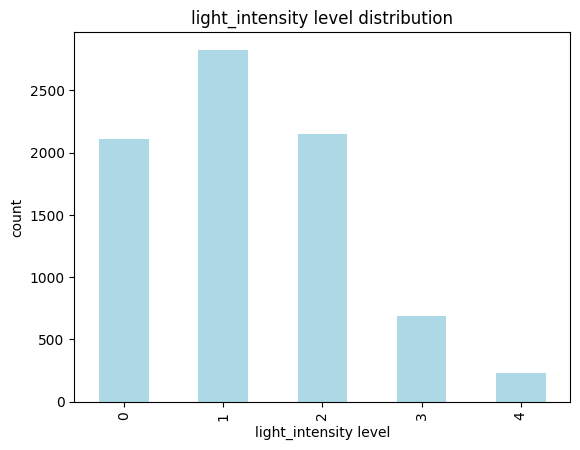

In [11]:
df.light_intensity.value_counts().sort_index().plot(kind="bar", color="lightblue")
plt.title("light_intensity level distribution")
plt.xlabel("light_intensity level")
plt.ylabel("count");

## fan_speed vs co2_level

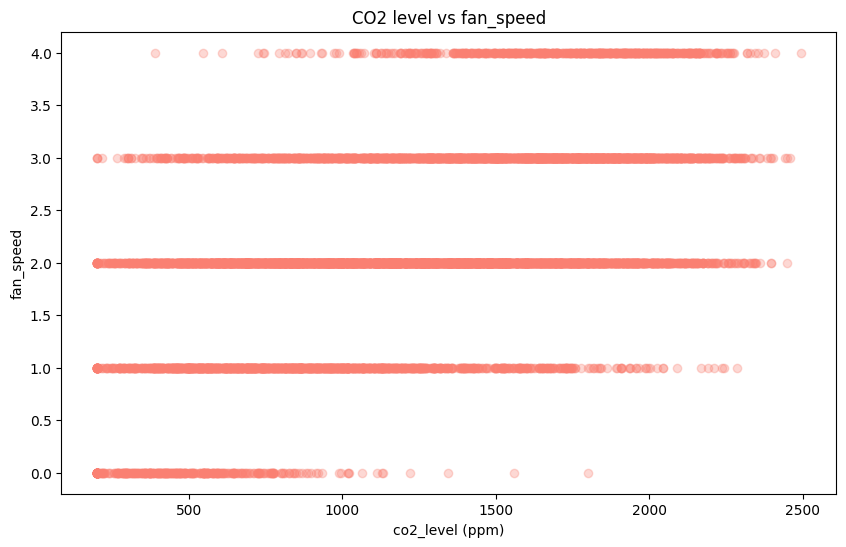

In [12]:
plt.figure(figsize=(10, 6))
plt.scatter(df["co2_level"], df["fan_speed"], c="salmon", alpha=0.3)
plt.title("CO2 level vs fan_speed")
plt.xlabel("co2_level (ppm)")
plt.ylabel("fan_speed");

## count vs fan_speed and light_intensity

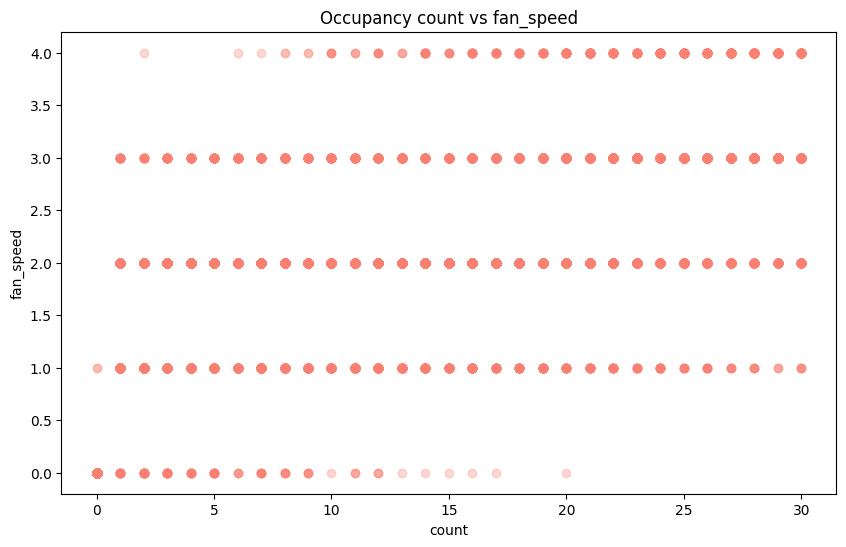

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(df["count"], df["fan_speed"], c="salmon", alpha=0.3)
plt.title("Occupancy count vs fan_speed")
plt.xlabel("count")
plt.ylabel("fan_speed");

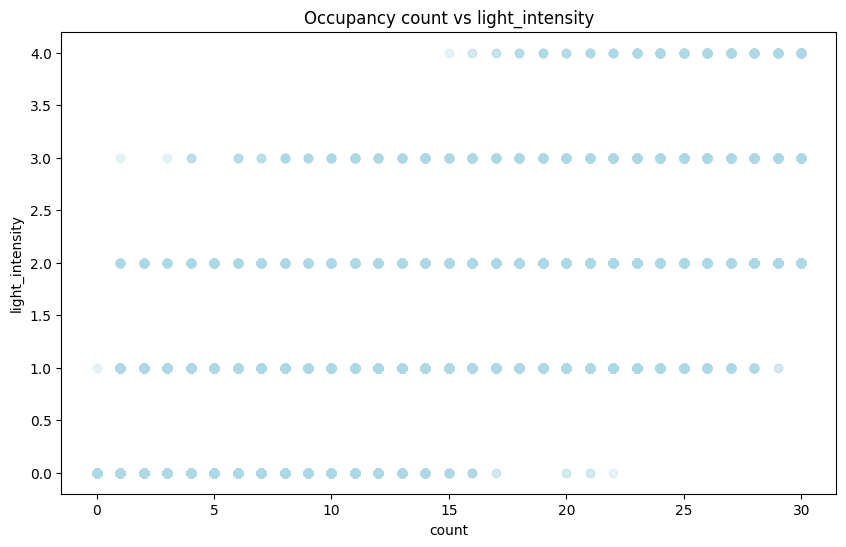

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(df["count"], df["light_intensity"], c="lightblue", alpha=0.3)
plt.title("Occupancy count vs light_intensity")
plt.xlabel("count")
plt.ylabel("light_intensity");

## Correlation

How strongly does each input feature relate to each target?

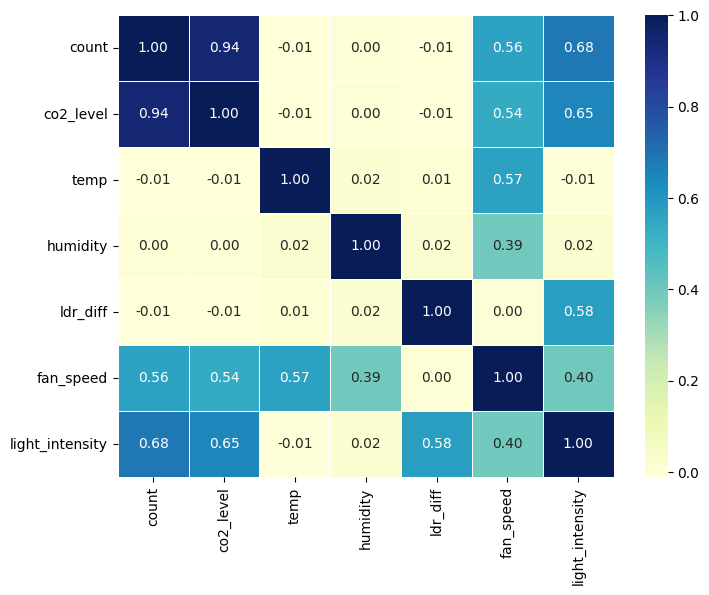

In [15]:
corr_matrix = df.corr()
fig, ax = plt.subplots(figsize=(8, 6))
ax = sns.heatmap(corr_matrix,
                  annot=True,
                  linewidths=0.5,
                  fmt=".2f",
                  cmap="YlGnBu");

# 5. Modelling - fan_speed

In [16]:
df.head()

,count,co2_level,temp,humidity,ldr_diff,fan_speed,light_intensity
0,26,1668,20.8,51.5,3115,1,4
1,9,846,48.4,52.8,-905,2,0
2,17,1359,37.7,50.7,-1106,2,1
3,4,689,37.0,65.1,2154,2,1
4,17,1469,49.8,65.0,2885,4,3


In [17]:
# Split data into X and y for fan_speed
X_fan = df[["count", "co2_level", "temp", "humidity"]]
y_fan = df["fan_speed"]

In [18]:
X_fan.head()

,count,co2_level,temp,humidity
0,26,1668,20.8,51.5
1,9,846,48.4,52.8
2,17,1359,37.7,50.7
3,4,689,37.0,65.1
4,17,1469,49.8,65.0


In [19]:
y_fan.head()

0    1
1    2
2    2
3    2
4    4
Name: fan_speed, dtype: int64

In [20]:
# split data into train and test sets
np.random.seed(42)

X_train_fan, X_test_fan, y_train_fan, y_test_fan = train_test_split(X_fan,
                                                                      y_fan,
                                                                      test_size=0.2)

In [21]:
X_train_fan.shape, X_test_fan.shape

((6400, 4), (1600, 4))

* We will find the patterns on the training set.
* We will use those patterns on the test set.
* Baseline model: a default `DecisionTreeClassifier` with no tuning.

In [22]:
# Baseline Decision Tree for fan_speed
np.random.seed(42)

dt_fan_baseline = DecisionTreeClassifier()
dt_fan_baseline.fit(X_train_fan, y_train_fan)
baseline_fan_score = dt_fan_baseline.score(X_test_fan, y_test_fan)
print(f"Baseline Decision Tree accuracy (fan_speed): {baseline_fan_score * 100:.2f}%")

Baseline Decision Tree accuracy (fan_speed): 79.12%


## Hyperparameter tuning with GridSearchCV (fan_speed)

An untuned Decision Tree tends to overfit (it will keep splitting until
every leaf is pure). We tune `max_depth`, `min_samples_split`,
`min_samples_leaf`, and `criterion` to find a tree that generalizes well
to the test set instead of memorizing the training set.

In [23]:
dt_grid = {"criterion": ["gini", "entropy"],
           "max_depth": [4, 5, 6, 7, 8],
           "min_samples_split": [5, 10, 20],
           "min_samples_leaf": [4, 8, 15, 25]}

np.random.seed(42)

gs_dt_fan = GridSearchCV(DecisionTreeClassifier(),
                          param_grid=dt_grid,
                          cv=5,
                          verbose=1,
                          n_jobs=-1)

gs_dt_fan.fit(X_train_fan, y_train_fan)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [4, 5, ...], 'min_samples_leaf': [4, 8, ...], 'min_samples_split': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter 

In [24]:
# check best hyperparameters
gs_dt_fan.best_params_

{'criterion': 'gini',
 'max_depth': 8,
 'min_samples_leaf': 4,
 'min_samples_split': 5}

In [25]:
# evaluate the tuned model
gs_dt_fan.score(X_test_fan, y_test_fan)

0.8125

## Evaluating the tuned fan_speed classifier

* Confusion matrix
* Classification report
* Feature importance

In [26]:
y_preds_fan = gs_dt_fan.predict(X_test_fan)
y_preds_fan

array([2, 3, 2, ..., 2, 2, 2], shape=(1600,))

In [27]:
# confusion matrix
print(confusion_matrix(y_test_fan, y_preds_fan))

[[ 70  16   0   0   0]
 [  7 220  44   0   0]
 [  0  38 583  58   0]
 [  0   0  91 343  16]
 [  0   0   0  30  84]]


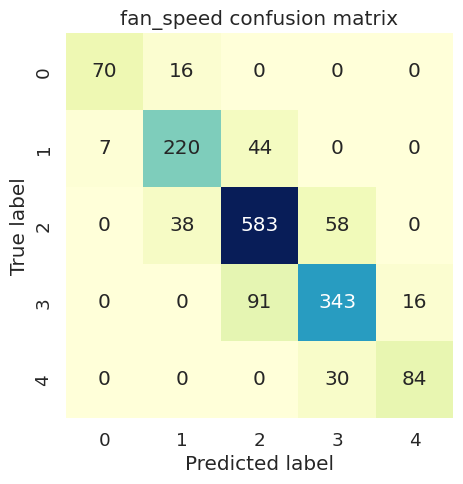

In [28]:
sns.set(font_scale=1.2)

def plot_conf_mat(y_test, y_preds, title):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                      annot=True,
                      fmt="d",
                      cbar=False,
                      cmap="YlGnBu")
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

plot_conf_mat(y_test_fan, y_preds_fan, "fan_speed confusion matrix")

In [29]:
print(classification_report(y_test_fan, y_preds_fan))

              precision    recall  f1-score   support

           0       0.91      0.81      0.86        86
           1       0.80      0.81      0.81       271
           2       0.81      0.86      0.83       679
           3       0.80      0.76      0.78       450
           4       0.84      0.74      0.79       114

    accuracy                           0.81      1600
   macro avg       0.83      0.80      0.81      1600
weighted avg       0.81      0.81      0.81      1600



# calculate evaluation metrics using cross validation

* use `cross_val_score()`

In [30]:
# check best hyperparameters again
gs_dt_fan.best_params_

{'criterion': 'gini',
 'max_depth': 8,
 'min_samples_leaf': 4,
 'min_samples_split': 5}

In [31]:
# create a fresh classifier with the best params found
best_dt_fan = DecisionTreeClassifier(**gs_dt_fan.best_params_)

# cross validated accuracy
cv_acc_fan = cross_val_score(best_dt_fan,
                              X_fan,
                              y_fan,
                              cv=5,
                              scoring="accuracy")
cv_acc_fan

array([0.79    , 0.799375, 0.78875 , 0.82    , 0.799375])

In [32]:
cv_acc_fan_mean = cv_acc_fan.mean()
print(f"Cross-validated accuracy (fan_speed): {cv_acc_fan_mean * 100:.2f}%")

Cross-validated accuracy (fan_speed): 79.95%


## Feature importance (fan_speed)

Which inputs did the tree rely on most to decide fan speed?

In [33]:
best_dt_fan.fit(X_train_fan, y_train_fan)

fan_feature_dict = dict(zip(X_fan.columns, best_dt_fan.feature_importances_))
fan_feature_dict

{'count': np.float64(0.3366329449397244),
 'co2_level': np.float64(0.031823027055597815),
 'temp': np.float64(0.3301079195675879),
 'humidity': np.float64(0.30143610843708996)}

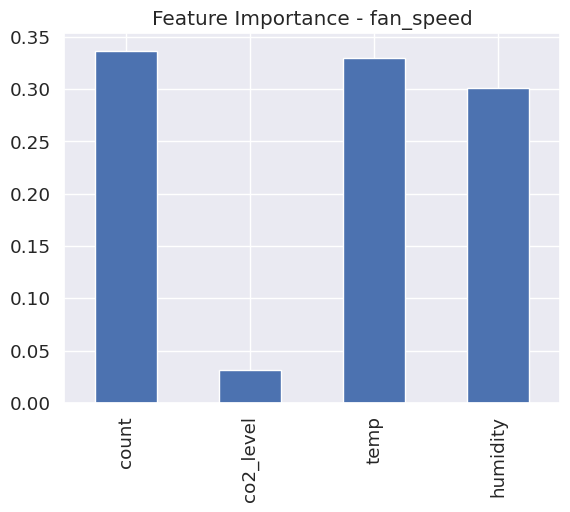

In [34]:
fan_feature_df = pd.DataFrame(fan_feature_dict, index=[0])
fan_feature_df.T.plot.bar(title="Feature Importance - fan_speed", legend=False);

## Visualizing the tree (fan_speed)

Limited to depth 3 here purely so it stays readable in the notebook.

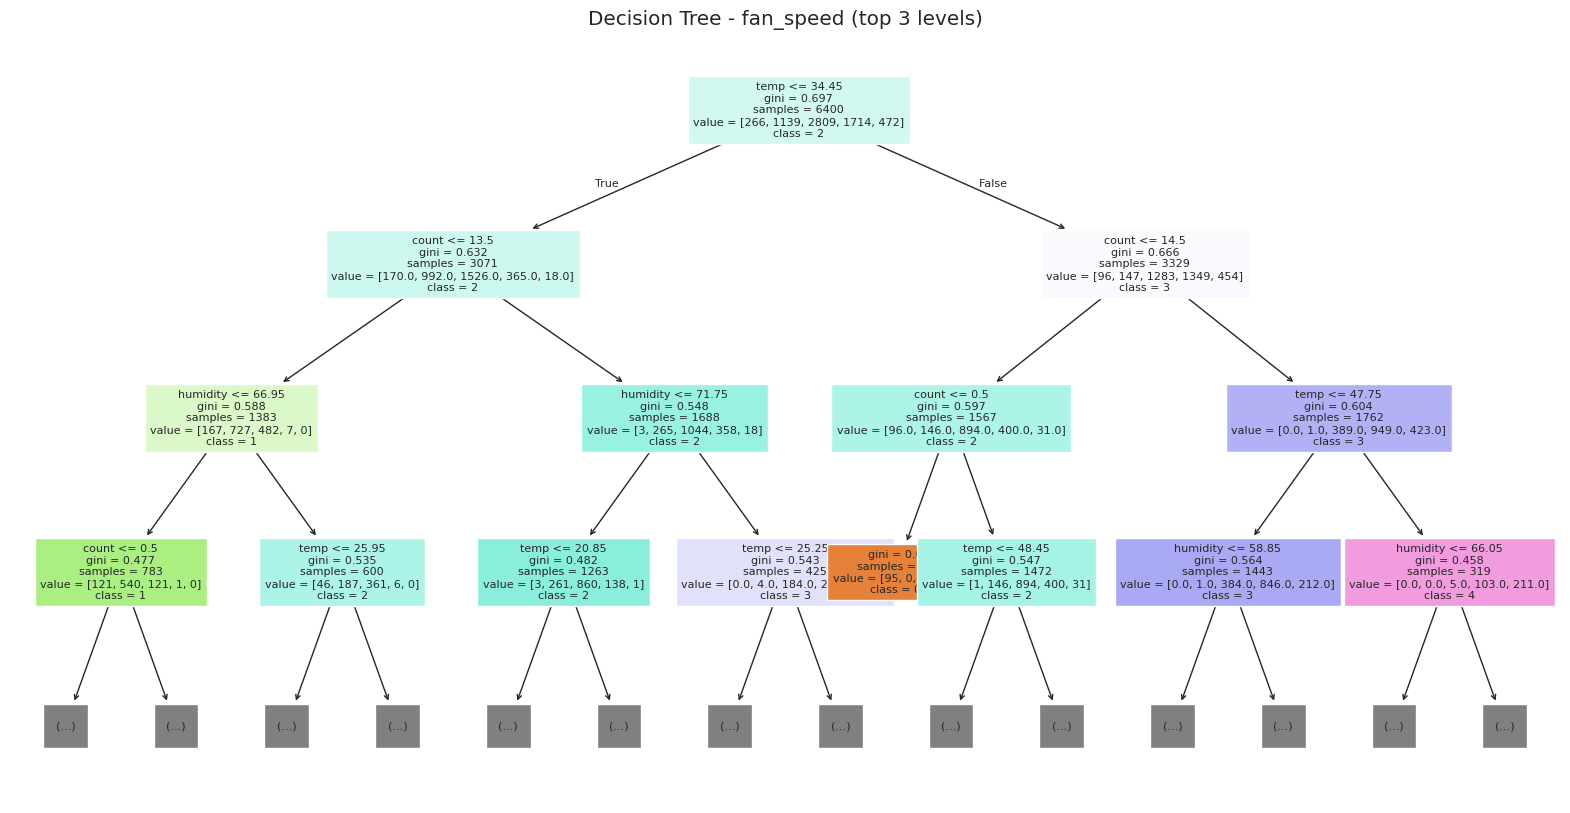

In [35]:
plt.figure(figsize=(20, 10))
plot_tree(best_dt_fan,
          feature_names=X_fan.columns,
          class_names=[str(c) for c in sorted(y_fan.unique())],
          filled=True,
          max_depth=3,
          fontsize=8)
plt.title("Decision Tree - fan_speed (top 3 levels)")
plt.show()

# 5b. Modelling - light_intensity

In [36]:
# Split data into X and y for light_intensity
X_light = df[["count", "co2_level", "ldr_diff"]]
y_light = df["light_intensity"]

In [37]:
np.random.seed(42)

X_train_light, X_test_light, y_train_light, y_test_light = train_test_split(X_light,
                                                                              y_light,
                                                                              test_size=0.2)
X_train_light.shape, X_test_light.shape

((6400, 3), (1600, 3))

In [38]:
# Baseline Decision Tree for light_intensity
np.random.seed(42)

dt_light_baseline = DecisionTreeClassifier()
dt_light_baseline.fit(X_train_light, y_train_light)
baseline_light_score = dt_light_baseline.score(X_test_light, y_test_light)
print(f"Baseline Decision Tree accuracy (light_intensity): {baseline_light_score * 100:.2f}%")

Baseline Decision Tree accuracy (light_intensity): 80.56%


## Hyperparameter tuning with GridSearchCV (light_intensity)

In [39]:
np.random.seed(42)

gs_dt_light = GridSearchCV(DecisionTreeClassifier(),
                            param_grid=dt_grid,
                            cv=5,
                            verbose=1,
                            n_jobs=-1)

gs_dt_light.fit(X_train_light, y_train_light)

Fitting 5 folds for each of 120 candidates, totalling 600 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [4, 5, ...], 'min_samples_leaf': [4, 8, ...], 'min_samples_split': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter 

In [40]:
gs_dt_light.best_params_

{'criterion': 'entropy',
 'max_depth': 8,
 'min_samples_leaf': 15,
 'min_samples_split': 5}

In [41]:
gs_dt_light.score(X_test_light, y_test_light)

0.86

## Evaluating the tuned light_intensity classifier

In [42]:
y_preds_light = gs_dt_light.predict(X_test_light)

print(confusion_matrix(y_test_light, y_preds_light))

[[382  41   0   0   0]
 [ 38 481  46   0   0]
 [  0  38 357  28   0]
 [  0   0  25 120   5]
 [  0   0   0   3  36]]


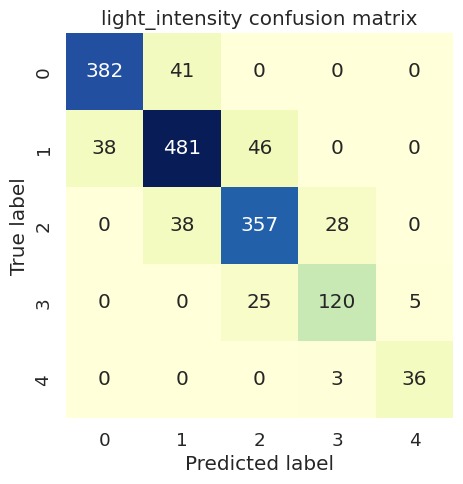

In [43]:
plot_conf_mat(y_test_light, y_preds_light, "light_intensity confusion matrix")

In [44]:
print(classification_report(y_test_light, y_preds_light))

              precision    recall  f1-score   support

           0       0.91      0.90      0.91       423
           1       0.86      0.85      0.86       565
           2       0.83      0.84      0.84       423
           3       0.79      0.80      0.80       150
           4       0.88      0.92      0.90        39

    accuracy                           0.86      1600
   macro avg       0.86      0.86      0.86      1600
weighted avg       0.86      0.86      0.86      1600



In [45]:
best_dt_light = DecisionTreeClassifier(**gs_dt_light.best_params_)

cv_acc_light = cross_val_score(best_dt_light,
                                X_light,
                                y_light,
                                cv=5,
                                scoring="accuracy")
cv_acc_light_mean = cv_acc_light.mean()
print(f"Cross-validated accuracy (light_intensity): {cv_acc_light_mean * 100:.2f}%")

Cross-validated accuracy (light_intensity): 85.50%


## Feature importance (light_intensity)

In [46]:
best_dt_light.fit(X_train_light, y_train_light)

light_feature_dict = dict(zip(X_light.columns, best_dt_light.feature_importances_))
light_feature_dict

{'count': np.float64(0.5125769655606756),
 'co2_level': np.float64(0.019478962187764008),
 'ldr_diff': np.float64(0.46794407225156043)}

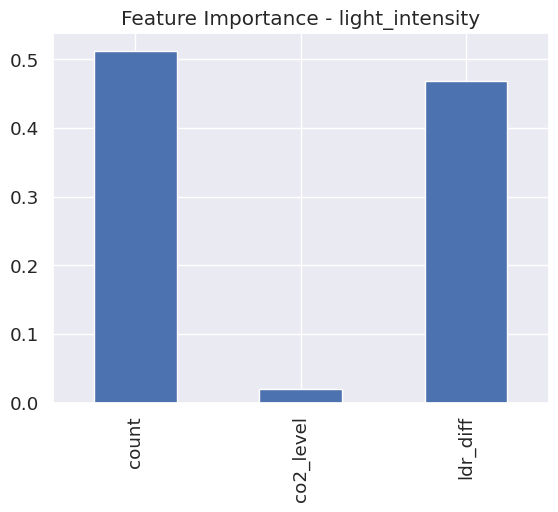

In [47]:
light_feature_df = pd.DataFrame(light_feature_dict, index=[0])
light_feature_df.T.plot.bar(title="Feature Importance - light_intensity", legend=False);

## Visualizing the tree (light_intensity)

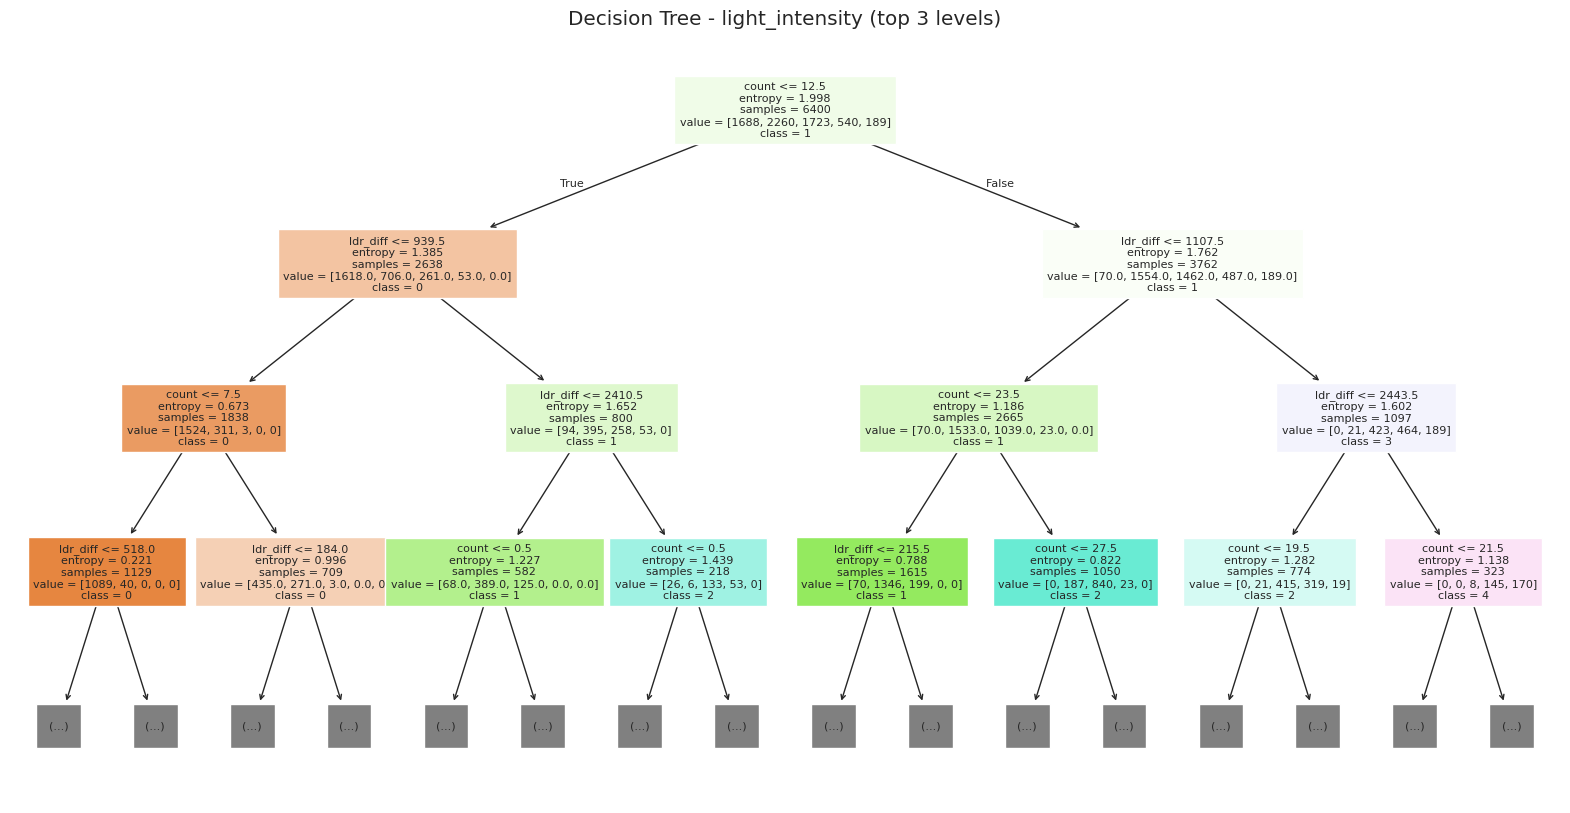

In [48]:
plt.figure(figsize=(20, 10))
plot_tree(best_dt_light,
          feature_names=X_light.columns,
          class_names=[str(c) for c in sorted(y_light.unique())],
          filled=True,
          max_depth=3,
          fontsize=8)
plt.title("Decision Tree - light_intensity (top 3 levels)")
plt.show()

## Model comparison summary

In [49]:
model_compare = pd.DataFrame({
    "fan_speed": [baseline_fan_score, gs_dt_fan.score(X_test_fan, y_test_fan), cv_acc_fan_mean],
    "light_intensity": [baseline_light_score, gs_dt_light.score(X_test_light, y_test_light), cv_acc_light_mean]
}, index=["baseline (untuned)", "tuned (GridSearchCV)", "cross-validated"])

model_compare

,fan_speed,light_intensity
baseline (untuned),0.79125,0.805625
tuned (GridSearchCV),0.81250,0.860000
cross-validated,0.79950,0.855000


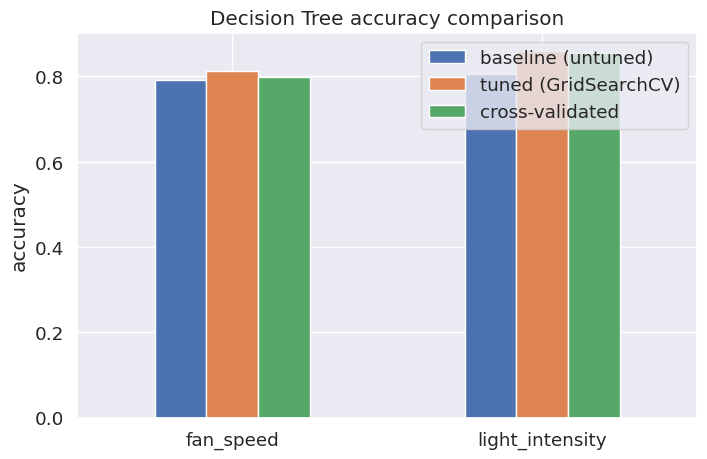

In [50]:
model_compare.T.plot.bar(figsize=(8, 5), title="Decision Tree accuracy comparison")
plt.ylabel("accuracy")
plt.xticks(rotation=0);

## Overfitting check

Test/CV accuracy alone doesn't tell us if the tree is overfitting - a model
can score well on a held-out split just by chance. The real check is
comparing TRAIN accuracy against TEST accuracy: a large gap (train much
higher than test) means the tree memorized noise in the training data
rather than learning the true pattern. As a rule of thumb, a gap under
~5 points is healthy for this kind of dataset; much more than that is a
sign to simplify the tree (lower `max_depth`, raise `min_samples_leaf`).

In [51]:
from sklearn.metrics import accuracy_score

fan_train_acc = accuracy_score(y_train_fan, best_dt_fan.predict(X_train_fan))
fan_test_acc = accuracy_score(y_test_fan, best_dt_fan.predict(X_test_fan))

light_train_acc = accuracy_score(y_train_light, best_dt_light.predict(X_train_light))
light_test_acc = accuracy_score(y_test_light, best_dt_light.predict(X_test_light))

overfit_check = pd.DataFrame({
    "fan_speed": [fan_train_acc, fan_test_acc, (fan_train_acc - fan_test_acc) * 100],
    "light_intensity": [light_train_acc, light_test_acc, (light_train_acc - light_test_acc) * 100]
}, index=["train accuracy", "test accuracy", "gap (points)"])

overfit_check

,fan_speed,light_intensity
train accuracy,0.851406,0.885781
test accuracy,0.812500,0.860000
gap (points),3.890625,2.578125
